In [2]:
# Importing required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Reading in the data
nifty_bank = pd.read_csv('https://raw.githubusercontent.com/huizhangky/CSE590/main/lecture-notebooks/NIFTYBank.csv',parse_dates=["Date"])
nifty_fmcg = pd.read_csv('https://raw.githubusercontent.com/huizhangky/CSE590/main/lecture-notebooks/NIFTYFMCG.csv',parse_dates=["Date"])
nifty_IT = pd.read_csv('https://raw.githubusercontent.com/huizhangky/CSE590/main/lecture-notebooks/NIFTYIT.csv',parse_dates=["Date"])
nifty_pharma = pd.read_csv('https://raw.githubusercontent.com/huizhangky/CSE590/main/lecture-notebooks/NIFTYPharma.csv',parse_dates=["Date"])

In [3]:
nifty_IT.head(5)

,Date,Open,High,Low,Close,Volume,Turnover,P/E,P/B,Div Yield
0,2000-01-03,0.0,0.0,0.0,45015.92,3777566.0,5.584100e+09,196.98,52.27,0.06
1,2000-01-04,0.0,0.0,0.0,48221.50,12128996.0,1.818670e+10,211.00,55.99,0.06
2,2000-01-05,0.0,0.0,0.0,46430.77,23400610.0,3.136010e+10,203.17,53.91,0.06
3,2000-01-06,0.0,0.0,0.0,44433.55,18408571.0,2.370960e+10,194.43,51.59,0.06
4,2000-01-07,0.0,0.0,0.0,41106.21,2762086.0,2.938500e+09,179.87,47.73,0.07


In [4]:
nifty_IT.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Volume              float64
Turnover            float64
P/E                 float64
P/B                 float64
Div Yield           float64
dtype: object

In [5]:
type(nifty_IT['Date'])

pandas.core.series.Series

In [6]:
sample_date = pd.to_datetime("2023/3/20")

# Get today's date
today = pd.to_datetime('today')

# Compare dates
if sample_date < today:
    print("The sample date is in the past.")
elif sample_date > today:
    print("The sample date is in the future.")
else:
    print("The sample date is today.")

The sample date is in the past.


In [29]:
sample_date > pd.to_datetime('10/11/23')

False

# A first look at NIFTY 50 data

In [30]:

nifty_bank_2019 = nifty_bank[nifty_bank['Date'] > '2019-12-31']
nifty_fmcg_2019 = nifty_fmcg[nifty_fmcg['Date'] > '2019-12-31']
nifty_IT_2019 = nifty_IT[nifty_IT['Date'] > '2019-12-31']
nifty_pharma_2019 = nifty_pharma[nifty_pharma['Date'] > '2019-12-31']
d = {
    'NIFTY Bank index': nifty_bank_2019['Close'].values,
    'NIFTY FMCG index': nifty_fmcg_2019['Close'].values,
    'NIFTY IT index': nifty_IT_2019['Close'].values,
    'NIFTY Pharma index': nifty_pharma_2019['Close'].values,
   }

# Inspecting the data
df = pd.DataFrame(data=d)
df.index=nifty_bank_2019['Date']
df.head()

,NIFTY Bank index,NIFTY FMCG index,NIFTY IT index,NIFTY Pharma index
Date,,,,
2020-01-01,32102.90,30234.25,15722.15,15722.15
2020-01-02,32443.85,30266.20,15709.65,15709.65
2020-01-03,32069.25,30109.25,15936.60,15936.60
2020-01-06,31237.15,29799.30,15879.80,15879.80
2020-01-07,31399.40,29861.80,15895.20,15895.20


# Plot with pandas: line plots

<AxesSubplot:xlabel='Date'>

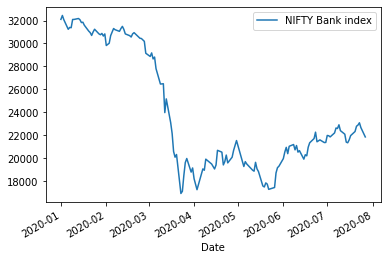

In [11]:
df.plot(y='NIFTY Bank index')

# Plotting parameters

The plot method has several parameters other than x and y, which can be tweaked to alter the plot.

* **x and y parameters** specify the values that you want on the x and y column. In the above case, these were the Date and the NIFTY Bank index column.
* **figsize** specifies the size of the figure object.
* **Title** to be used for the plot.
* **legend** to be placed on-axis subplots.
* **Style**: the matplotlib line style per column.
* **X and y labe**l: name to use for the label on the x-axis and y-axis. 
* **Subplots**: make separate subplots for each column.
* **Kind**: the kind of plot to produce. We’ll look at this parameter in detail in the upcoming sections.
Let’s now plot the same dataframe with some more arguments, like specifying the **figsize** and **labels**:

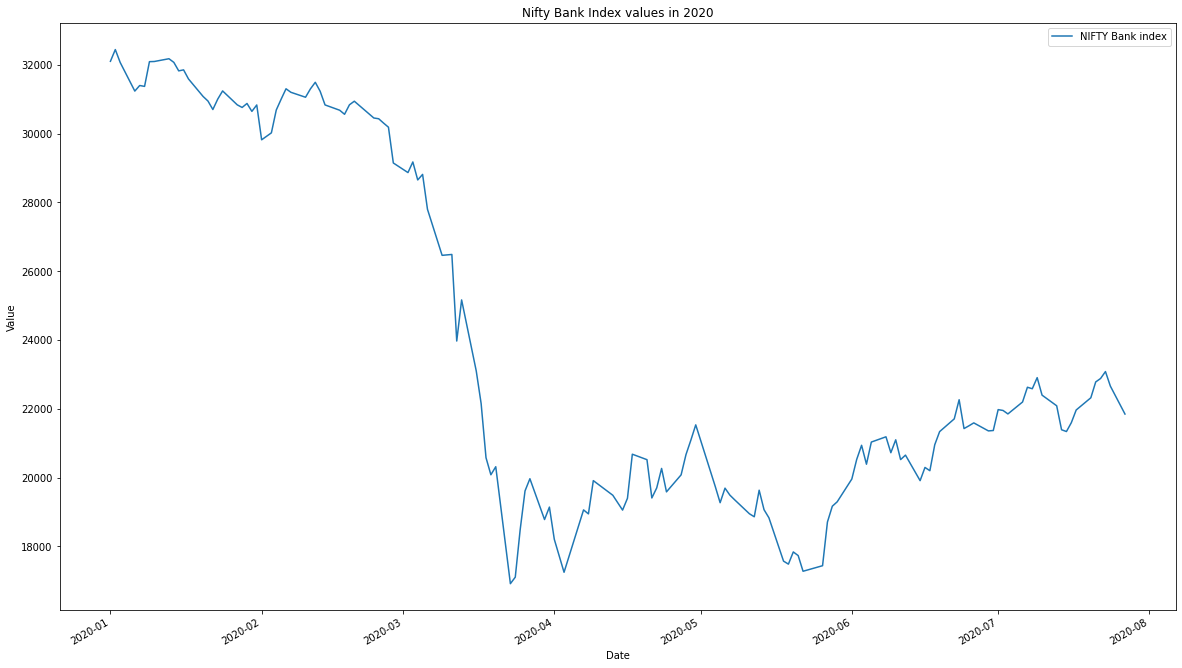

In [12]:
df.plot(y='NIFTY Bank index',figsize=(20,12),title='Nifty Bank Index values in 2020',ylabel = 'Value');

# Use the *kind* parameter. This parameter accepts string values and determines which kind of plot you’ll create. 

In [33]:
df_sample = df.resample(rule = 'W').mean()[:5]
df_sample

,NIFTY Bank index,NIFTY FMCG index,NIFTY IT index,NIFTY Pharma index
Date,,,,
2020-01-05,32205.333333,30203.233333,15789.466667,15789.466667
2020-01-12,31640.000000,30009.670000,15922.700000,15922.700000
2020-01-19,31903.750000,31161.120000,16334.670000,16334.670000
2020-01-26,30995.090000,31285.530000,16332.810000,16332.810000
2020-02-02,30629.616667,30918.566667,16342.883333,16342.883333


**rule = 'M' - resample by month;  'Y' - by year; 'W' - by week**

**bar plots**

<AxesSubplot:xlabel='Date'>

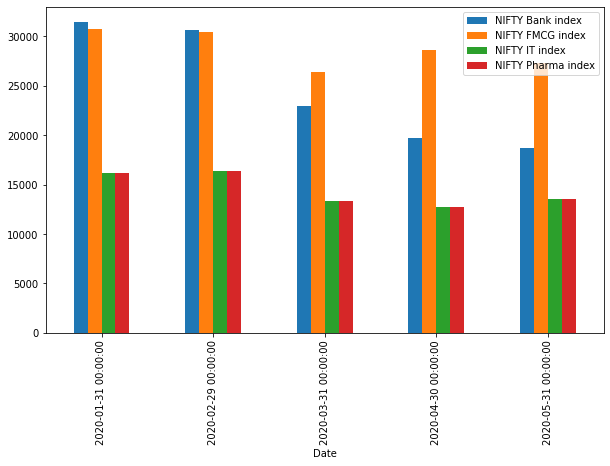

In [17]:
df_sample.plot(kind='bar',figsize=(10,6))

**horizontal bar plots**

<AxesSubplot:ylabel='Date'>

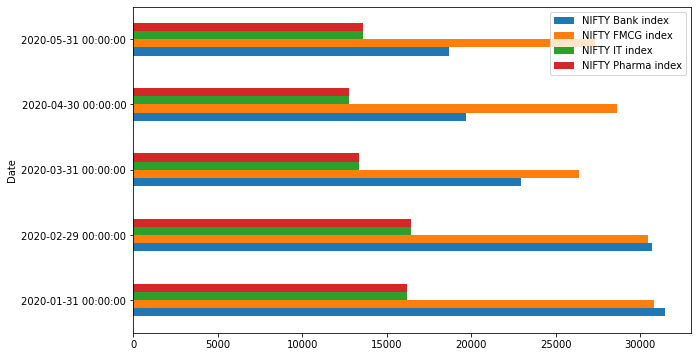

In [18]:
df_sample.plot(kind='barh',figsize=(10,6))

**stacked bar charts**

<AxesSubplot:ylabel='Date'>

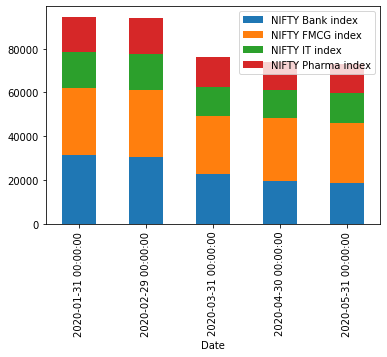

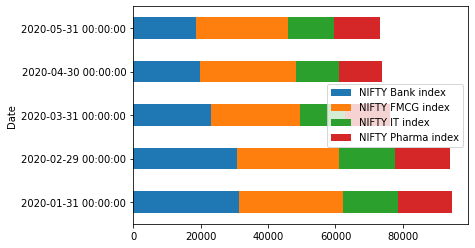

In [19]:
df_sample.plot(kind='bar',stacked=True) # for vertical barplot
df_sample.plot(kind='barh',stacked=True) # for Horizontal barplot

**Histograms**

<AxesSubplot:ylabel='Frequency'>

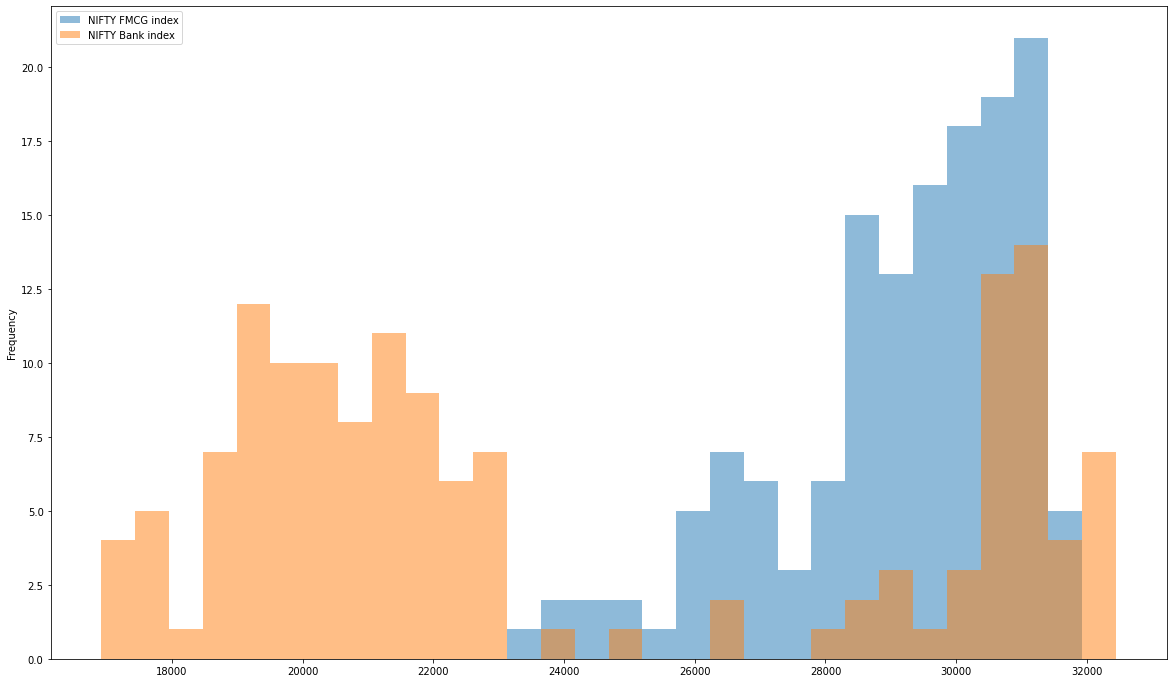

In [20]:
df[['NIFTY FMCG index','NIFTY Bank index']].plot(kind='hist',bins=30,alpha=0.5, figsize=(20,12))

**KDE plots**

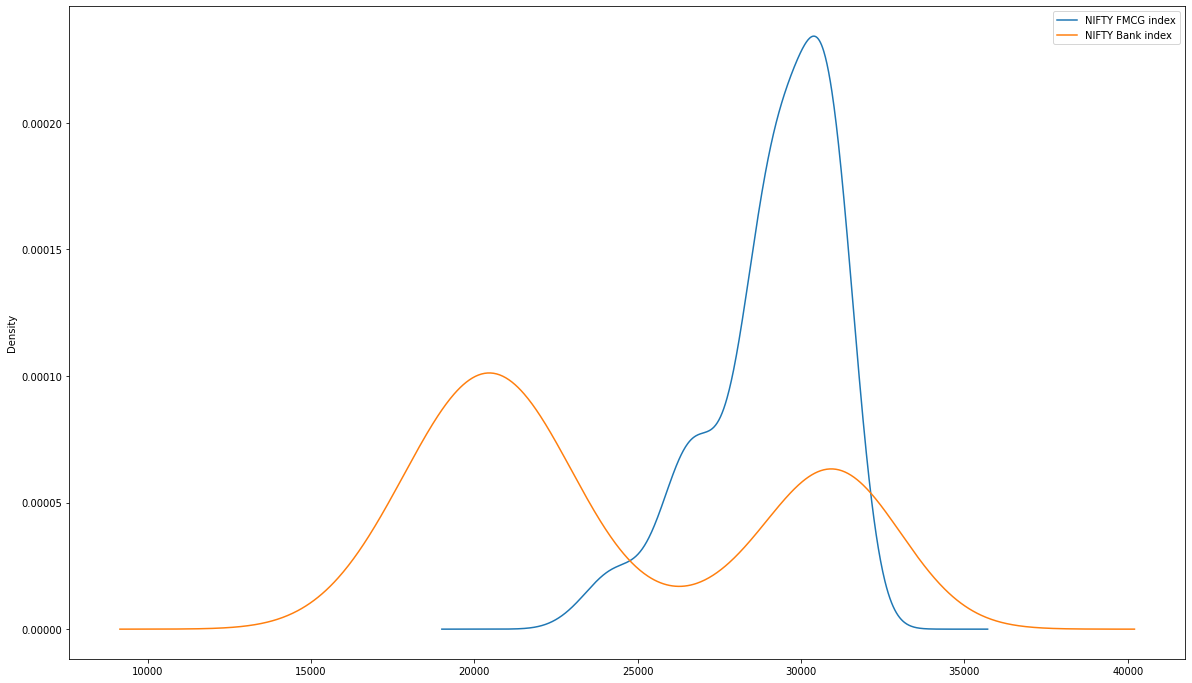

In [14]:
df[['NIFTY FMCG index','NIFTY Bank index']].plot(kind='kde', figsize=(20,12));

**Box plots**

<AxesSubplot:>

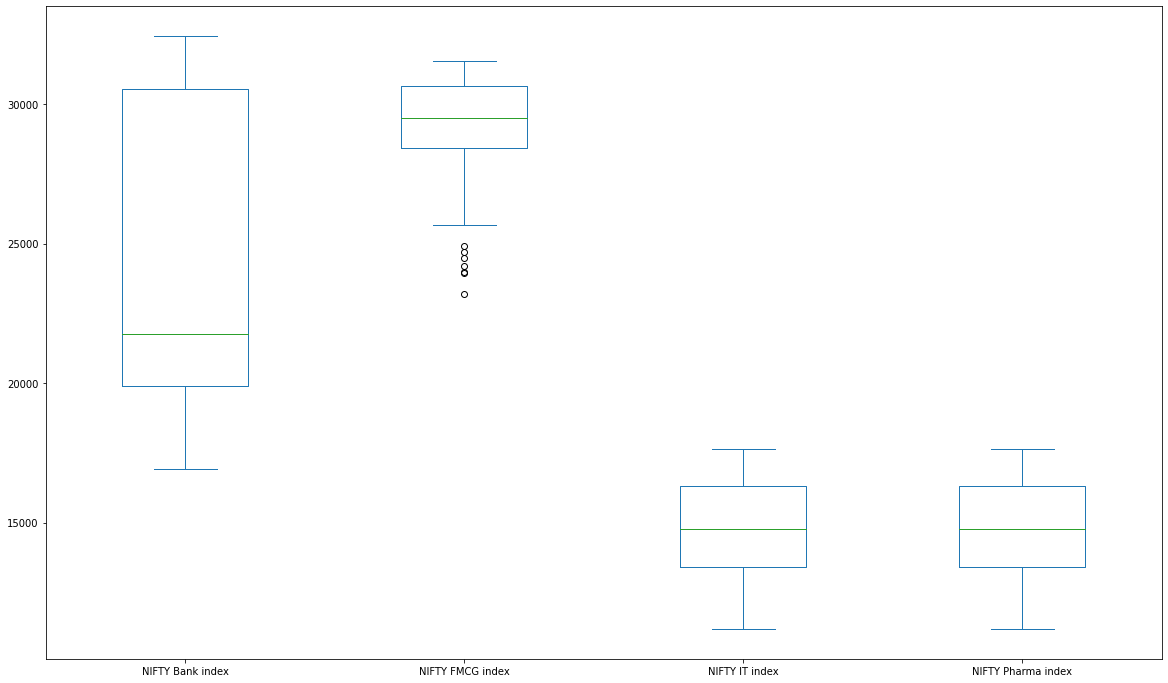

In [15]:
df.plot(kind='box',figsize=(20,12))

In [ ]:
df.plot(kind='box',figsize=(20,12),vert=False)

**Area plots**

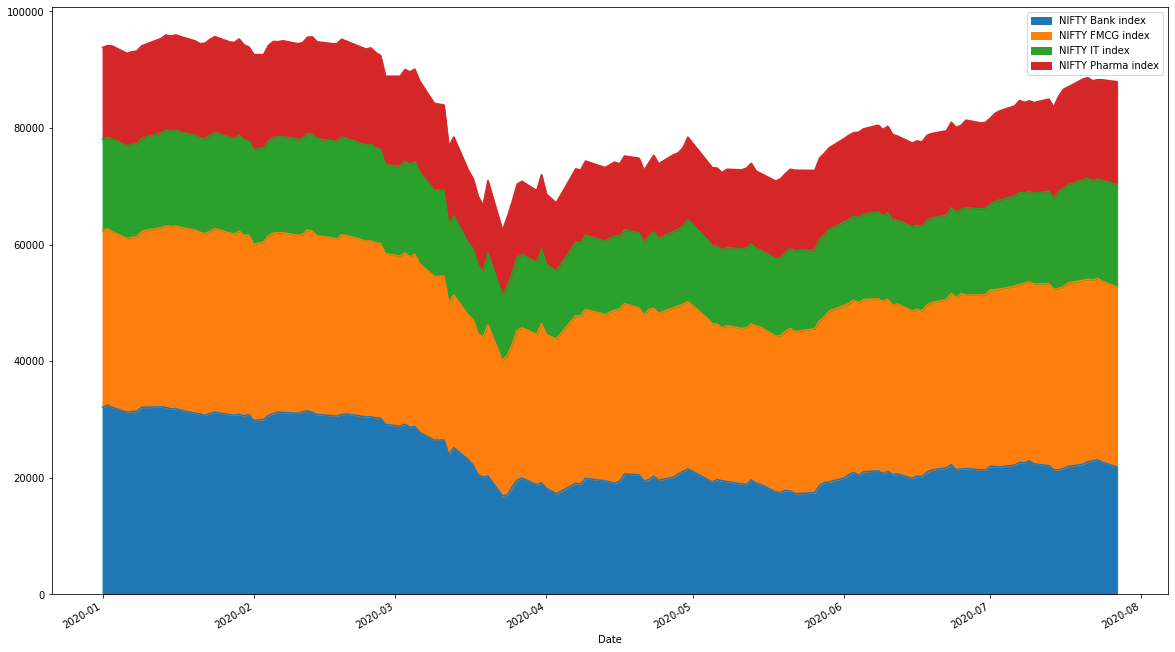

In [16]:
df.plot(kind='area',figsize=(20,12));

**Scatter plot**

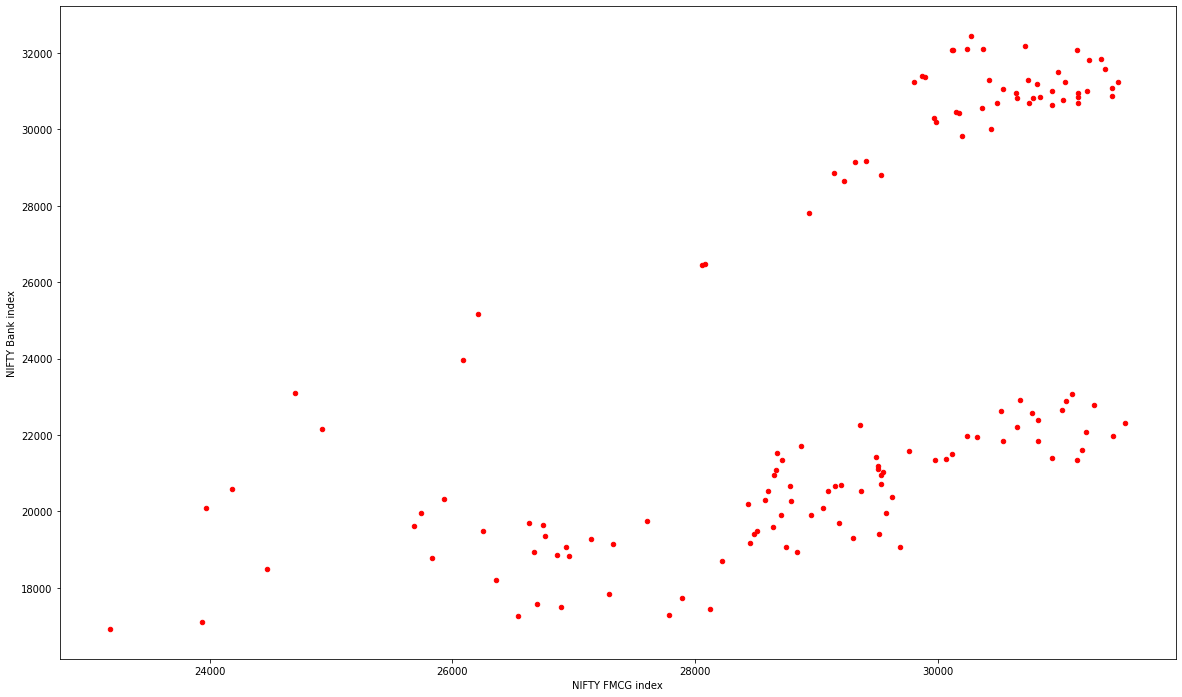

In [17]:
df.plot(kind='scatter',x='NIFTY FMCG index', y='NIFTY Bank index',figsize=(20,12),color='Red');

**Pie plot**

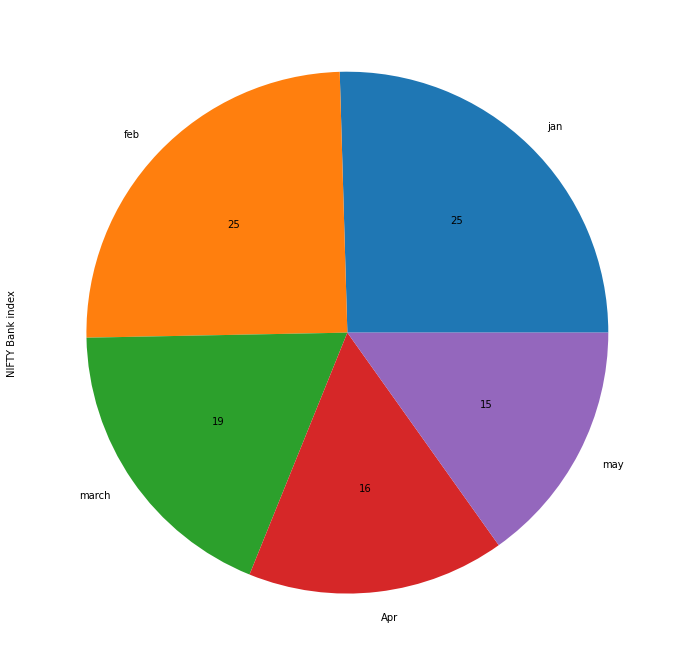

In [18]:
df_sample.index=['jan','feb','march','Apr','may']
df_sample['NIFTY Bank index'].plot.pie(legend=False, autopct='%.f', figsize=(20,12));

# Working with DateTime in Pandas

**Convert strings to datetime**

**Pandas to_datetime()** is able to parse any valid date string to datetime without any additional arguments. For example:

In [21]:
import pandas as pd
import numpy as np

df = pd.DataFrame({'date': ['3/10/2000', '3/11/2000', '3/12/2000'],
                   'value': [2, 3, 4]})
df['date'] = pd.to_datetime(df['date'])
df

,date,value
0,2000-03-10,2
1,2000-03-11,3
2,2000-03-12,4


**Day first format**

By default, **to_datetime()** will parse string with month first **(MM/DD, MM DD, or MM-DD)** format, and this arrangement is relatively unique in the United State.
In most of the rest of the world, the day is written first **(DD/MM, DD MM, or DD-MM)**. If you would like Pandas to consider day first instead of month, you can set the argument dayfirst to True.

In [22]:
df = pd.DataFrame({'date': ['3/10/2000', '3/11/2000', '3/12/2000'],
                   'value': [2, 3, 4]})
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df

,date,value
0,2000-10-03,2
1,2000-11-03,3
2,2000-12-03,4


In [23]:
df.dtypes

date     datetime64[ns]
value             int64
dtype: object

**Custome format**

By default, strings are parsed using the Pandas built-in parser from dateutil.parser.parse. Sometimes, your strings might be in a custom format, for example, YYYY-DD-MM HH:MM:SS. **Pandas to_datetime() has an argument called format that allows you to pass a custom format**:

In [24]:
df = pd.DataFrame({'date': ['2016-6-10 20:30:0', 
                            '2016-7-1 19:45:30', 
                            '2013-10-12 4:5:1'],
                   'value': [2, 3, 4]})
df['date'] = pd.to_datetime(df['date'], format="%Y-%d-%m %H:%M:%S")
df

,date,value
0,2016-10-06 20:30:00,2
1,2016-01-07 19:45:30,3
2,2013-12-10 04:05:01,4


**Handle parsing error**

Handle parsing error

You will end up with a TypeError if the date string does not meet the timestamp format.

In [25]:
df = pd.DataFrame({'date': ['3/10/2000', 'a/11/2000', '3/12/2000'],
                   'value': [2, 3, 4]})
df['date'] = pd.to_datetime(df['date'])

ValueError: ('Unknown string format:', 'a/11/2000')

In [26]:
df['date'] = pd.to_datetime(df['date'], errors='ignore')
df

,date,value
0,3/10/2000,2
1,a/11/2000,3
2,3/12/2000,4


In [24]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df

,date,value
0,2000-03-10,2
1,NaT,3
2,2000-03-12,4


**Assemble a datetime from multiple columns**

In [25]:
df = pd.DataFrame({'year': [2015, 2016],
                   'month': [2, 3],
                   'day': [4, 5]})
df['date'] = pd.to_datetime(df)
df

,year,month,day,date
0,2015,2,4,2015-02-04
1,2016,3,5,2016-03-05


**Get year, month, and day**

In [27]:
df = pd.DataFrame({'name': ['Tom', 'Andy', 'Lucas'],
                 'DoB': ['08-05-1997', '04-28-1996', '12-16-1995']})
df['DoB'] = pd.to_datetime(df['DoB'])

In [28]:
df['year']= df['DoB'].dt.year
df['month']= df['DoB'].dt.month
df['day']= df['DoB'].dt.day
df

,name,DoB,year,month,day
0,Tom,1997-08-05,1997,8,5
1,Andy,1996-04-28,1996,4,28
2,Lucas,1995-12-16,1995,12,16


**Use offset**

In [29]:
import pandas as pd 
my_dict={'NAME':['Ravi','Raju','Alex'],
         'dt_start':['31/1/2020','29/2/2020','28/2/2019']
         }
df = pd.DataFrame(data=my_dict)
df['dt_start'] = pd.to_datetime(df['dt_start'])
print(df)

   NAME   dt_start
0  Ravi 2020-01-31
1  Raju 2020-02-29
2  Alex 2019-02-28


In [30]:
df['dt_end']=df['dt_start']+pd.DateOffset(days=365)
print(df)

   NAME   dt_start     dt_end
0  Ravi 2020-01-31 2021-01-30
1  Raju 2020-02-29 2021-02-28
2  Alex 2019-02-28 2020-02-28


In [31]:
df['dt_end']=df['dt_start']+\
  pd.DateOffset(hours=2,minutes=50,seconds=43)

print(df)

   NAME   dt_start              dt_end
0  Ravi 2020-01-31 2020-01-31 02:50:43
1  Raju 2020-02-29 2020-02-29 02:50:43
2  Alex 2019-02-28 2019-02-28 02:50:43


# An example of Air Quality Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
air_quality = pd.read_csv("https://raw.githubusercontent.com/huizhangky/CSE590/main/lecture-notebooks/airquality.csv")
air_quality = air_quality.rename(columns={"date.utc": "datetime"})
air_quality.head()

,city,country,datetime,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


In [33]:
air_quality.city.unique()

array(['Paris', 'Antwerpen', 'London'], dtype=object)

In [34]:
air_quality.location.unique()

array(['FR04014', 'BETR801', 'London Westminster'], dtype=object)

In [35]:
air_quality["datetime"] = pd.to_datetime(air_quality["datetime"])
air_quality["datetime"]


0      2019-06-21 00:00:00+00:00
1      2019-06-20 23:00:00+00:00
2      2019-06-20 22:00:00+00:00
3      2019-06-20 21:00:00+00:00
4      2019-06-20 20:00:00+00:00
                  ...           
2063   2019-05-07 06:00:00+00:00
2064   2019-05-07 04:00:00+00:00
2065   2019-05-07 03:00:00+00:00
2066   2019-05-07 02:00:00+00:00
2067   2019-05-07 01:00:00+00:00
Name: datetime, Length: 2068, dtype: datetime64[ns, UTC]

In [36]:
air_quality["datetime"].min(), air_quality["datetime"].max()

(Timestamp('2019-05-07 01:00:00+0000', tz='UTC'),
 Timestamp('2019-06-21 00:00:00+0000', tz='UTC'))

In [37]:
air_quality["datetime"].max() - air_quality["datetime"].min()

Timedelta('44 days 23:00:00')

In [38]:
air_quality["month"] = air_quality["datetime"].dt.month
air_quality.head()

,city,country,datetime,location,parameter,value,unit,month
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,6
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,6
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,6
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,6
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,6


In [39]:
air_quality.groupby([air_quality["datetime"].dt.weekday, "location"])["value"].mean()


datetime  location          
0         BETR801               27.875000
          FR04014               24.856250
          London Westminster    23.969697
1         BETR801               22.214286
          FR04014               30.999359
          London Westminster    24.885714
2         BETR801               21.125000
          FR04014               29.165753
          London Westminster    23.460432
3         BETR801               27.500000
          FR04014               28.600690
          London Westminster    24.780142
4         BETR801               28.400000
          FR04014               31.617986
          London Westminster    26.446809
5         BETR801               33.500000
          FR04014               25.266154
          London Westminster    24.977612
6         BETR801               21.896552
          FR04014               23.274306
          London Westminster    24.859155
Name: value, dtype: float64

**Plot the typical NO2 pattern during the day of our time series of all stations together. In other words, what is the average value for each hour of the day?**

Text(0.5, 0, 'Hour of the day')

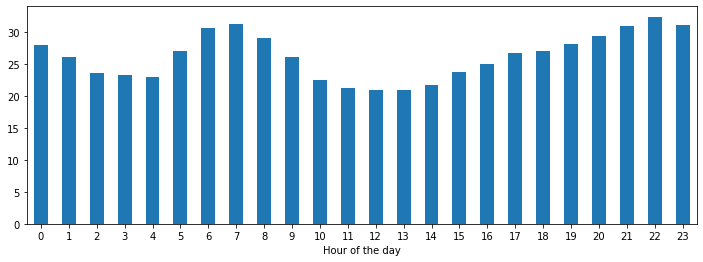

In [40]:
fig, axs = plt.subplots(figsize=(12, 4))

air_quality.groupby(air_quality["datetime"].dt.hour)["value"].mean().plot(
    kind='bar', rot=0, ax=axs
)

plt.xlabel("Hour of the day")
plt.xlabel("Hour of the day")

In [41]:
no_2 = air_quality.pivot(index="datetime", columns="location", values="value")

no_2.head()

location,BETR801,FR04014,London Westminster
datetime,,,
2019-05-07 01:00:00+00:00,50.5,25.0,23.0
2019-05-07 02:00:00+00:00,45.0,27.7,19.0
2019-05-07 03:00:00+00:00,NaN,50.4,19.0
2019-05-07 04:00:00+00:00,NaN,61.9,16.0
2019-05-07 05:00:00+00:00,NaN,72.4,NaN


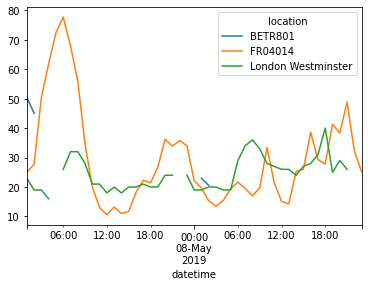

In [42]:
no_2["2019-05-07":"2019-05-08"].plot();